In [13]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"dhanujgoyal","key":"e75f739f9c8d1fc44b50d416d6744269"}'}

In [14]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [15]:
!kaggle datasets list -s tiger

ref                                                        title                                               size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------------------------  --------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
quadeer15sh/amur-tiger-reidentification                    Amur Tiger Re-identification                   237664889  2022-06-10 09:07:37.670000           2297         54  0.9411765        
iluvchicken/cheetah-jaguar-and-tiger                       Cheetah, Hyena, Jaguar and Tiger                       0  2020-06-02 06:30:50.163000           4822         37  0.625            
nidzsharma/tiger-save-the-tiger-before-its-long-gone       Tiger Reserve Statistics                            4843  2023-03-27 05:51:09.460000            371          8  1                
akrsnv/lions-and-tigers                                

In [16]:
!ls -la ~/.kaggle


total 16
drwxr-xr-x 2 root root 4096 Jun 30 05:06 .
drwx------ 1 root root 4096 Jun 30 05:06 ..
-rw------- 1 root root   67 Jun 30 05:06 kaggle.json


In [17]:
import os

print(os.path.exists('/root/.kaggle/kaggle.json'))


True


In [18]:
!kaggle datasets download -d quadeer15sh/amur-tiger-reidentification

Dataset URL: https://www.kaggle.com/datasets/quadeer15sh/amur-tiger-reidentification
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
100% 227M/227M [00:02<00:00, 116MB/s]



In [19]:
!unzip -q amur-tiger-reidentification.zip -d tiger_dataset

In [20]:
import os

for root, dirs, files in os.walk('/content/tiger_dataset'):
    print(root)

/content/tiger_dataset
/content/tiger_dataset/Amur Tigers
/content/tiger_dataset/Amur Tigers/train
/content/tiger_dataset/Amur Tigers/test


In [21]:
for root, dirs, files in os.walk('/content/tiger_dataset'):
    if len(files) > 0:
        print(root, len(files))

/content/tiger_dataset/Amur Tigers 5
/content/tiger_dataset/Amur Tigers/train 3393
/content/tiger_dataset/Amur Tigers/test 1765


In [22]:
import os

train_path = "/content/tiger_dataset/Amur Tigers/train"

print(os.listdir(train_path)[:20])

['003577.jpg', '004809.jpg', '001740.jpg', '002509.jpg', '004599.jpg', '000831.jpg', '000682.jpg', '000340.jpg', '002066.jpg', '003839.jpg', '002019.jpg', '000295.jpg', '005033.jpg', '000923.jpg', '002375.jpg', '000107.jpg', '003022.jpg', '002685.jpg', '002173.jpg', '002423.jpg']


In [23]:
import os

base_path = "/content/tiger_dataset/Amur Tigers"

for file in os.listdir(base_path):
    print(file)

reid_keypoints_test.json
reid_list_test.csv
reid_keypoints_train.json
train
reid_list_train.csv
LICENSE
test


In [24]:
import pandas as pd

train_csv = pd.read_csv(
    "/content/tiger_dataset/Amur Tigers/reid_list_train.csv"
)

train_csv.head()

,250,003597.jpg
0,256,003523.jpg
1,171,003900.jpg
2,247,002636.jpg
3,238,002249.jpg
4,264,003370.jpg


In [25]:
print(train_csv.columns)

Index(['250', '003597.jpg'], dtype='object')


In [26]:
train_csv.head(10)

,250,003597.jpg
0,256,003523.jpg
1,171,003900.jpg
2,247,002636.jpg
3,238,002249.jpg
4,264,003370.jpg
5,54,001260.jpg
6,237,001015.jpg
7,255,003460.jpg
8,96,004922.jpg
9,114,001532.jpg


In [27]:
import os

for root, dirs, files in os.walk('/content'):
    for file in files:
        if 'reid_list_train' in file:
            print(os.path.join(root, file))

/content/tiger_dataset/Amur Tigers/reid_list_train.csv


In [28]:
!ls /content


 amur-tiger-reidentification.zip   kaggle.json	 tiger_dataset
'kaggle (1).json'		   sample_data


In [29]:
!ls "/content/tiger_dataset"

'Amur Tigers'


In [30]:
!ls "/content/tiger_dataset/Amur Tigers"

LICENSE			  reid_keypoints_train.json  reid_list_train.csv  train
reid_keypoints_test.json  reid_list_test.csv	     test


In [31]:
import pandas as pd

train_csv = pd.read_csv(
    "/content/tiger_dataset/Amur Tigers/reid_list_train.csv",
    header=None
)

train_csv.columns = [
    "Tiger_ID",
    "Image_Name"
]

print(train_csv.head())

print("\nTotal Images:", len(train_csv))

print(
    "\nTotal Unique Tigers:",
    train_csv["Tiger_ID"].nunique()
)

   Tiger_ID  Image_Name
0       250  003597.jpg
1       256  003523.jpg
2       171  003900.jpg
3       247  002636.jpg
4       238  002249.jpg

Total Images: 1887

Total Unique Tigers: 107


In [32]:
train_csv["Tiger_ID"].value_counts().head(20)

,count
Tiger_ID,
153,98
160,97
154,49
246,48
243,41
136,38
265,38
249,37
237,37


In [34]:
print("Total Unique Tigers:", train_csv["Tiger_ID"].nunique())
print("Total Images:", len(train_csv))

Total Unique Tigers: 107
Total Images: 1887


In [35]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

train_csv["label"] = le.fit_transform(train_csv["Tiger_ID"])

print("Number of Classes:", len(le.classes_))
train_csv.head()

Number of Classes: 107


,Tiger_ID,Image_Name,label
0,250,003597.jpg,93
1,256,003523.jpg,97
2,171,003900.jpg,62
3,247,002636.jpg,91
4,238,002249.jpg,86


In [36]:
import os

image_dir = "/content/tiger_dataset/Amur Tigers/train"

train_csv["path"] = train_csv["Image_Name"].apply(
    lambda x: os.path.join(image_dir, x)
)

train_csv.head()

,Tiger_ID,Image_Name,label,path
0,250,003597.jpg,93,/content/tiger_dataset/Amur Tigers/train/00359...
1,256,003523.jpg,97,/content/tiger_dataset/Amur Tigers/train/00352...
2,171,003900.jpg,62,/content/tiger_dataset/Amur Tigers/train/00390...
3,247,002636.jpg,91,/content/tiger_dataset/Amur Tigers/train/00263...
4,238,002249.jpg,86,/content/tiger_dataset/Amur Tigers/train/00224...


In [37]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    train_csv,
    test_size=0.2,
    random_state=42,
    stratify=train_csv["label"]
)

print(len(train_df))
print(len(val_df))

1509
378


In [38]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    rescale=1./255
)

In [39]:
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="path",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="raw"
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="path",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="raw"
)

Found 1509 validated image filenames.
Found 378 validated image filenames.


In [40]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [41]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([

    base_model,

    GlobalAveragePooling2D(),

    Dense(
        512,
        activation='relu'
    ),

    Dropout(0.5),

    Dense(
        107,
        activation='softmax'
    )

])

In [42]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [44]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=2
)

Epoch 1/2
48/48 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.1445 - loss: 4.0962 - val_accuracy: 0.3413 - val_loss: 3.1879
Epoch 2/2
48/48 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.3082 - loss: 2.8988 - val_accuracy: 0.5079 - val_loss: 2.3177


In [45]:
model.save("tiger_reid_model.h5")

In [46]:
from google.colab import files
uploaded = files.upload()

Saving Screenshot 2026-06-30 104930.png to Screenshot 2026-06-30 104930.png


In [47]:
import numpy as np
from tensorflow.keras.preprocessing import image

file_name = list(uploaded.keys())[0]

img = image.load_img(
    file_name,
    target_size=(224,224)
)

img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

pred = model.predict(img_array)

pred_id = np.argmax(pred)

real_tiger_id = le.inverse_transform([pred_id])[0]

print("Predicted Tiger ID:", real_tiger_id)
print("Confidence:", round(np.max(pred)*100,2), "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 820ms/step
Predicted Tiger ID: 168
Confidence: 11.81 %


In [48]:
import os

test_dir = "/content/tiger_dataset/Amur Tigers/test"

print(os.listdir(test_dir)[:10])

['004379.jpg', '004461.jpg', '005030.jpg', '001362.jpg', '004059.jpg', '002460.jpg', '002281.jpg', '002099.jpg', '000278.jpg', '000377.jpg']


In [50]:
import os

test_dir = "/content/tiger_dataset/Amur Tigers/test"

images = os.listdir(test_dir)

print("Total test images:", len(images))
print(images[:20])

Total test images: 1765
['004379.jpg', '004461.jpg', '005030.jpg', '001362.jpg', '004059.jpg', '002460.jpg', '002281.jpg', '002099.jpg', '000278.jpg', '000377.jpg', '000282.jpg', '000101.jpg', '003727.jpg', '002640.jpg', '000698.jpg', '004620.jpg', '004735.jpg', '001862.jpg', '000962.jpg', '000686.jpg']


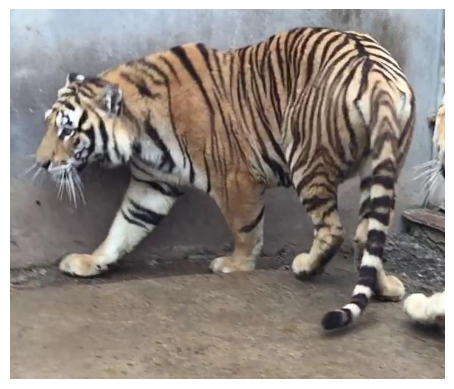

In [51]:
from PIL import Image
import matplotlib.pyplot as plt

img_path = "/content/tiger_dataset/Amur Tigers/test/004379.jpg"

img = Image.open(img_path)

plt.imshow(img)
plt.axis("off")
plt.show()

Image: 004379.jpg


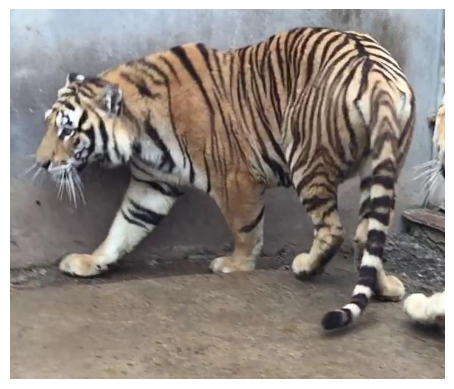

In [52]:
import os
from PIL import Image
import matplotlib.pyplot as plt

test_dir = "/content/tiger_dataset/Amur Tigers/test"

file_name = os.listdir(test_dir)[0]

img_path = os.path.join(test_dir, file_name)

print("Image:", file_name)

img = Image.open(img_path)

plt.imshow(img)
plt.axis("off")
plt.show()

In [53]:
import numpy as np
from tensorflow.keras.preprocessing import image

file_name = "/content/tiger_dataset/Amur Tigers/test/004379.jpg"

img = image.load_img(
    file_name,
    target_size=(224,224)
)

img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

pred = model.predict(img_array)

pred_id = np.argmax(pred)

real_tiger_id = le.inverse_transform([pred_id])[0]

print("Predicted Tiger ID:", real_tiger_id)
print("Confidence:", round(np.max(pred)*100,2), "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Predicted Tiger ID: 139
Confidence: 8.93 %


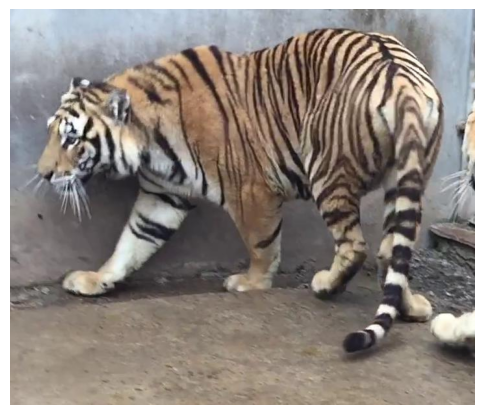

In [54]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("/content/tiger_dataset/Amur Tigers/test/004379.jpg")

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")
plt.show()

In [55]:
print(history.history['accuracy'][-1])
print(history.history['val_accuracy'][-1])

0.30815109610557556
0.5079365372657776
